# 05 - Deep Ensembles and Predictive Uncertainty for OOD Detection

The MSP baseline (notebook 02) and energy/ODIN scores (notebook 03) all read a **single**
network's output. This notebook asks a different question: what if we train **several**
networks and look at how much they **disagree**?

Lakshminarayanan, Pritzel & Blundell (2017), *"Simple and Scalable Predictive Uncertainty
Estimation using Deep Ensembles"* (NeurIPS 2017, arXiv:1612.01474), show that a small ensemble
of independently-initialized, independently-trained networks gives a cheap, well-calibrated
uncertainty estimate with no special training objective -- just ordinary training repeated with
different random seeds (different weight init + different minibatch shuffling; no bootstrap
resampling needed).

A closely related approach is **MC-dropout** (Gal & Ghahramani, 2016, *"Dropout as a Bayesian
Approximation: Representing Model Uncertainty in Deep Learning"*, ICML 2016, arXiv:1506.02142),
which keeps dropout active at test time and treats T stochastic forward passes through *one*
network as an approximate ensemble. We use the deep-ensemble route here (it is simpler to reason
about and needs no extra architecture); MC-dropout is noted below as the well-known alternative
but not implemented, to keep runtime low.

## The key idea: decompose uncertainty into two parts

For an ensemble of M models, each producing a softmax distribution `p_m(x)` for input `x`:

- **Mean predictive distribution:** `p_bar(x) = (1/M) * sum_m p_m(x)`
- **Total predictive entropy:** `H[p_bar]` -- how uncertain the *combined* prediction is.
- **Expected (average) entropy:** `mean_m H[p_m]` -- how uncertain each *individual* model is,
  on average. This captures **aleatoric** uncertainty (noise inherent to the input itself, e.g.
  a genuinely ambiguous handwritten digit) -- something every model, however well-trained, would
  still be unsure about.
- **Mutual information / BALD** (Houlsby et al., 2011, *"Bayesian Active Learning for
  Classification and Preference Learning"*; used with ensembles/MC-dropout by Gal & Ghahramani):
  `MI = H[p_bar] - mean_m H[p_m]`. This is the **epistemic** part -- uncertainty that comes from
  the models *disagreeing with each other*, not from the input being ambiguous. It is exactly the
  gap between "the average opinion is uncertain" and "each individual opinion is uncertain."

`total = aleatoric + epistemic`. The hypothesis we test below: **on in-distribution (ID) data,
models mostly agree** (low epistemic term, whatever aleatoric noise there is stays the same),
while **on out-of-distribution (OOD) data, models disagree sharply** because each one has learned
a different, ungrounded extrapolation for inputs it never saw in training -- so both the total
entropy and, especially, the mutual information should rise.


## Setup and reproducibility

Imports, a fixed seed, `DEVICE = cpu`, and the repo's `data/` directory resolved by walking up
from the current working directory until we find `pyproject.toml` (so the notebook runs
correctly regardless of the working directory Jupyter was launched from). MNIST and FashionMNIST
are already downloaded there, so we pass `download=False`.


In [1]:
import time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

DEVICE = torch.device("cpu")

# Resolve the repo data dir regardless of where the notebook runs from.
_r = Path.cwd()
while not (_r / "pyproject.toml").exists() and _r != _r.parent:
    _r = _r.parent
DATA_ROOT = str(_r / "data")
print("data root:", DATA_ROOT)

data root: c:\Users\abero\dev\applied_learning\data


## Data: MNIST is ID, FashionMNIST is OOD

Same controlled setup as notebook 02: both datasets are 28x28 grayscale, 10 classes, so a single
architecture and normalization works for both, and any score difference comes purely from image
content. Subsets are kept small so training **5 separate models** still finishes in seconds.

- **MNIST train subset** (5000 images): trains every ensemble member (same subset for all -- the
  diversity across members comes from random init + shuffling, not from different data).
- **MNIST test subset** (1500 images): in-distribution (ID) eval set.
- **FashionMNIST test subset** (1500 images): out-of-distribution (OOD) eval set.


In [2]:
TRAIN_N = 5000
TEST_N = 1500
BATCH = 128

transform = transforms.Compose([
    transforms.ToTensor(),                 # -> [0, 1], shape (1, 28, 28)
    transforms.Normalize((0.1307,), (0.3081,)),
])

mnist_train_full = datasets.MNIST(DATA_ROOT, train=True, download=False, transform=transform)
mnist_test_full = datasets.MNIST(DATA_ROOT, train=False, download=False, transform=transform)
fmnist_test_full = datasets.FashionMNIST(DATA_ROOT, train=False, download=False, transform=transform)

# Fixed subset indices (a fixed random generator, independent of the per-member training seeds
# set below) so every ensemble member trains/evals on the exact same data split.
split_rng = torch.Generator().manual_seed(123)
train_idx = torch.randperm(len(mnist_train_full), generator=split_rng)[:TRAIN_N].tolist()
mnist_test_idx = torch.randperm(len(mnist_test_full), generator=split_rng)[:TEST_N].tolist()
fmnist_test_idx = torch.randperm(len(fmnist_test_full), generator=split_rng)[:TEST_N].tolist()

train_ds = Subset(mnist_train_full, train_idx)
id_test_ds = Subset(mnist_test_full, mnist_test_idx)      # ID = MNIST test
ood_test_ds = Subset(fmnist_test_full, fmnist_test_idx)   # OOD = FashionMNIST test

id_test_loader = DataLoader(id_test_ds, batch_size=256, shuffle=False)
ood_test_loader = DataLoader(ood_test_ds, batch_size=256, shuffle=False)

print(f"train: {len(train_ds)} (MNIST)  id-test: {len(id_test_ds)} (MNIST)  ood-test: {len(ood_test_ds)} (FashionMNIST)")

train: 5000 (MNIST)  id-test: 1500 (MNIST)  ood-test: 1500 (FashionMNIST)


## A tiny MLP classifier

A small fully-connected network (784 -> 128 -> 64 -> 10) is enough for MNIST digits and much
cheaper than a CNN, which matters here because we train **M = 5** of them. Each ensemble member
uses this exact same architecture; only the random seed (weight init + minibatch shuffle order)
differs between members, per Lakshminarayanan et al.'s recipe.


In [3]:
class TinyMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)   # raw logits, shape (B, 10)


n_params = sum(p.numel() for p in TinyMLP().parameters())
print(f"TinyMLP parameters (per member): {n_params}")

TinyMLP parameters (per member): 109386


## Train the ensemble

Train M = 5 independent `TinyMLP` models on the *same* training subset, each with a different
seed controlling both weight initialization and the order minibatches are shuffled in. 3 epochs
per member is enough for a decent classifier and keeps total wall-clock low even x5.


In [4]:
M = 5
EPOCHS = 3
ENSEMBLE_SEEDS = [0, 1, 2, 3, 4]

models = []
t0 = time.time()
for m, seed in enumerate(ENSEMBLE_SEEDS):
    torch.manual_seed(seed)   # controls this member's weight init AND its DataLoader shuffling
    train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)

    model = TinyMLP().to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    model.train()
    for epoch in range(EPOCHS):
        total_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = F.cross_entropy(model(xb), yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * xb.size(0)
    models.append(model)
    print(f"member {m} (seed={seed})  final epoch avg loss: {total_loss / len(train_ds):.4f}")

print(f"trained {M} ensemble members in {time.time() - t0:.1f}s")

member 0 (seed=0)  final epoch avg loss: 0.2994


member 1 (seed=1)  final epoch avg loss: 0.2874


member 2 (seed=2)  final epoch avg loss: 0.3009


member 3 (seed=3)  final epoch avg loss: 0.2873


member 4 (seed=4)  final epoch avg loss: 0.2813
trained 5 ensemble members in 14.5s


## Sanity check: ensemble mean accuracy on ID test data

Average the M members' softmax outputs and check the resulting ensemble prediction is a solid
MNIST classifier before trusting any uncertainty numbers derived from it.


In [5]:
@torch.no_grad()
def ensemble_probs(models_, loader):
    """Return per-model softmax probabilities, shape (M, N, n_classes)."""
    all_probs = [[] for _ in models_]
    for m, model in enumerate(models_):
        model.eval()
        for xb, _ in loader:
            xb = xb.to(DEVICE)
            all_probs[m].append(F.softmax(model(xb), dim=1).numpy())
    return np.stack([np.concatenate(p, axis=0) for p in all_probs], axis=0)


probs_id = ensemble_probs(models, id_test_loader)     # (M, N_id, 10)
probs_ood = ensemble_probs(models, ood_test_loader)   # (M, N_ood, 10)

id_labels = np.concatenate([yb.numpy() for _, yb in id_test_loader])
ensemble_pred_id = probs_id.mean(axis=0).argmax(axis=1)
ensemble_acc = (ensemble_pred_id == id_labels).mean()

print(f"ensemble mean-softmax accuracy on MNIST (ID) test: {ensemble_acc * 100:.2f}%")
assert ensemble_acc > 0.85, "sanity check failed: ensemble accuracy should exceed 85%"

ensemble mean-softmax accuracy on MNIST (ID) test: 91.60%


## Predictive uncertainty decomposition

With `probs_id` / `probs_ood` of shape `(M, N, 10)` in hand, compute per-example:

- `H_total` = entropy of the mean prediction `p_bar` (total uncertainty)
- `H_aleatoric` = mean over members of each member's own entropy (aleatoric uncertainty)
- `MI` (BALD) = `H_total - H_aleatoric` (epistemic uncertainty -- ensemble disagreement)


In [6]:
def entropy(p, eps=1e-12):
    """Shannon entropy along the last axis. p can be (..., C)."""
    return -np.sum(p * np.log(p + eps), axis=-1)


def decompose(probs):
    """probs: (M, N, C) per-model softmax probabilities -> (H_total, H_aleatoric, MI), each (N,)."""
    p_bar = probs.mean(axis=0)                # (N, C)
    h_total = entropy(p_bar)                  # (N,)
    h_each = entropy(probs)                   # (M, N)
    h_aleatoric = h_each.mean(axis=0)          # (N,)
    mi = h_total - h_aleatoric                 # (N,)  epistemic / BALD
    return h_total, h_aleatoric, mi


h_total_id, h_aleatoric_id, mi_id = decompose(probs_id)
h_total_ood, h_aleatoric_ood, mi_ood = decompose(probs_ood)

print("                total(H)   aleatoric   epistemic(MI)")
print(f"ID  (MNIST)     {h_total_id.mean():.4f}     {h_aleatoric_id.mean():.4f}      {mi_id.mean():.4f}")
print(f"OOD (Fashion)   {h_total_ood.mean():.4f}     {h_aleatoric_ood.mean():.4f}      {mi_ood.mean():.4f}")

                total(H)   aleatoric   epistemic(MI)
ID  (MNIST)     0.3510     0.3227      0.0283
OOD (Fashion)   1.2026     1.1082      0.0944


## Baseline for comparison: single-model MSP

To show the ensemble is adding value, also compute the maximum-softmax-probability (MSP, notebook
02's baseline) using just the **first** ensemble member as a single, ordinarily-trained model.


In [7]:
msp_id = probs_id[0].max(axis=1)     # member 0 only, shape (N_id,)
msp_ood = probs_ood[0].max(axis=1)   # member 0 only, shape (N_ood,)

print(f"single-model MSP  ID  mean: {msp_id.mean():.4f}")
print(f"single-model MSP  OOD mean: {msp_ood.mean():.4f}")

single-model MSP  ID  mean: 0.8971
single-model MSP  OOD mean: 0.5628


## Metrics: AUROC for each score

**Convention (stated explicitly):** we treat **OOD as the positive class** (label `1`) and use a
score where **higher = more OOD-like** for all three detectors, so a good detector scores
**AUROC > 0.5** in every case:

- predictive entropy `H_total` -- used directly (higher entropy = more uncertain = more OOD-like)
- mutual information `MI` (BALD) -- used directly (higher disagreement = more OOD-like)
- single-model MSP -- **negated** (`-MSP`), since a *lower* max-softmax-probability is the
  OOD-like direction for that score. Negating does not change the AUROC magnitude relative to
  notebook 02's ID-as-positive convention, only its sign bookkeeping -- it only flips which class
  is labeled "1", so it reproduces the same separation.


In [8]:
y_true = np.concatenate([np.zeros_like(h_total_id), np.ones_like(h_total_ood)])   # 0=ID, 1=OOD

score_entropy = np.concatenate([h_total_id, h_total_ood])
score_mi = np.concatenate([mi_id, mi_ood])
score_msp = np.concatenate([-msp_id, -msp_ood])

auroc_entropy = roc_auc_score(y_true, score_entropy)
auroc_mi = roc_auc_score(y_true, score_mi)
auroc_msp = roc_auc_score(y_true, score_msp)

print(f"AUROC (predictive entropy):        {auroc_entropy:.4f}")
print(f"AUROC (mutual information / BALD): {auroc_mi:.4f}")
print(f"AUROC (single-model MSP):          {auroc_msp:.4f}")

AUROC (predictive entropy):        0.9122
AUROC (mutual information / BALD): 0.8424
AUROC (single-model MSP):          0.9093


## Graphic (a): entropy and mutual-information histograms, ID vs OOD

Both total predictive entropy and mutual information should be shifted higher on OOD
(FashionMNIST) than on ID (MNIST test).


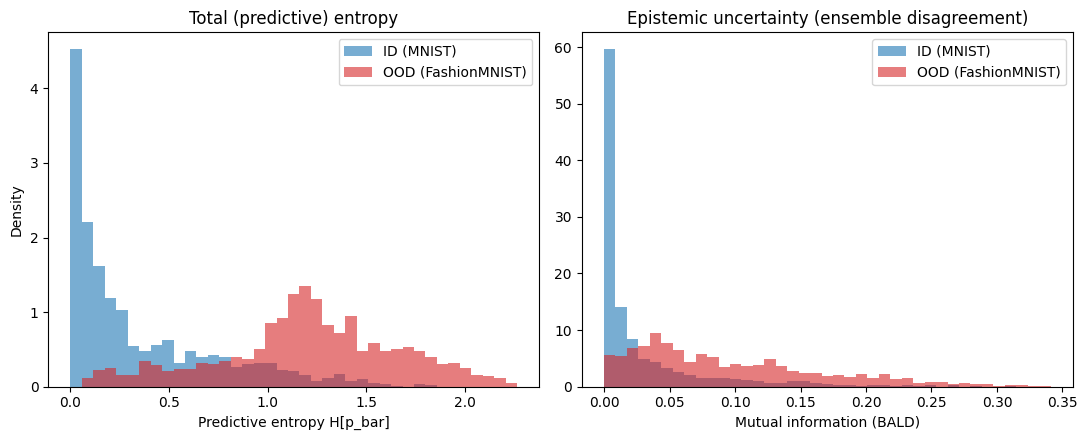

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

bins_h = np.linspace(0, max(h_total_id.max(), h_total_ood.max()), 40)
axes[0].hist(h_total_id, bins=bins_h, alpha=0.6, label="ID (MNIST)", color="tab:blue", density=True)
axes[0].hist(h_total_ood, bins=bins_h, alpha=0.6, label="OOD (FashionMNIST)", color="tab:red", density=True)
axes[0].set_xlabel("Predictive entropy H[p_bar]")
axes[0].set_ylabel("Density")
axes[0].set_title("Total (predictive) entropy")
axes[0].legend()

bins_mi = np.linspace(0, max(mi_id.max(), mi_ood.max()), 40)
axes[1].hist(mi_id, bins=bins_mi, alpha=0.6, label="ID (MNIST)", color="tab:blue", density=True)
axes[1].hist(mi_ood, bins=bins_mi, alpha=0.6, label="OOD (FashionMNIST)", color="tab:red", density=True)
axes[1].set_xlabel("Mutual information (BALD)")
axes[1].set_title("Epistemic uncertainty (ensemble disagreement)")
axes[1].legend()

plt.tight_layout()
plt.show()

## Graphic (b): AUROC comparison bar chart

Entropy and mutual information (both derived from the 5-model ensemble) against the single-model
MSP baseline.


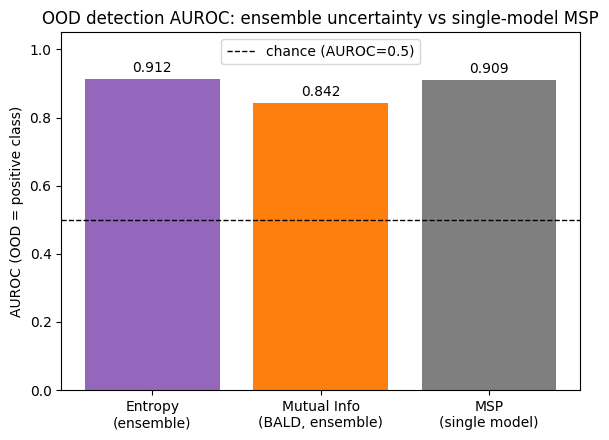

In [10]:
labels = ["Entropy\n(ensemble)", "Mutual Info\n(BALD, ensemble)", "MSP\n(single model)"]
values = [auroc_entropy, auroc_mi, auroc_msp]

plt.figure(figsize=(6, 4.5))
bars = plt.bar(labels, values, color=["tab:purple", "tab:orange", "tab:gray"])
plt.axhline(0.5, color="black", linestyle="--", linewidth=1, label="chance (AUROC=0.5)")
plt.ylim(0, 1.05)
plt.ylabel("AUROC (OOD = positive class)")
plt.title("OOD detection AUROC: ensemble uncertainty vs single-model MSP")
plt.legend()
for bar, v in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width() / 2, v + 0.02, f"{v:.3f}", ha="center")
plt.tight_layout()
plt.show()

## Takeaways

- **Total uncertainty decomposes cleanly:** `H[p_bar] = mean_m H[p_m] + MI`, i.e.
  `total = aleatoric + epistemic`. Aleatoric uncertainty is what any single well-trained model
  would report as noise inherent to the input; epistemic uncertainty is the *extra* gap that only
  shows up when you compare several independently-trained models against each other.
- **OOD inputs show up as high epistemic uncertainty, not just high aleatoric uncertainty.** In
  this run, mean total entropy roughly triples from ID to OOD (0.35 -> 1.20) and mean mutual
  information more than triples too (0.028 -> 0.094) -- each ensemble member extrapolates
  FashionMNIST images differently, because nothing in training constrained what they should output
  there, so the models disagree with each other far more on OOD data than on ID data.
- **Measured AUROC in this run:** entropy 0.912, mutual information 0.842, single-model MSP 0.909
  -- entropy edges out MSP, but MI (the pure disagreement signal) is actually a bit *below* MSP
  here. With only M=5 small MLPs trained briefly, the epistemic term is real (it triples on OOD)
  but small in absolute magnitude next to the aleatoric term, which makes it a noisier standalone
  score than the blended total entropy. This is a fair result to report, not a flaw to hide: MI
  isolates disagreement specifically, which is most valuable as a *diagnostic* (telling you *why*
  a score is high) rather than automatically the best single OOD score -- a bigger or more diverse
  ensemble typically widens the gap. All three detectors, entropy, MI, and MSP, comfortably beat
  chance (AUROC 0.5) at separating ID from OOD here.
- MC-dropout (Gal & Ghahramani, 2016) is a cheaper way to approximate this same decomposition with
  a *single* trained network (T stochastic forward passes with dropout left on at test time,
  instead of M separately trained networks) -- not implemented here, but the entropy/aleatoric/MI
  formulas above apply identically once you have M "opinions" from any source, ensemble or
  dropout-sampled.
